## Browse-only rendering

This notebook is generated from `scripts/nmme_comparison.py` purely for **browsing on GitHub** — code plus every figure, no clone or run required.

It is **not** part of the reproducibility contract. The authoritative source is the script under `scripts/`; regenerate the manuscript figures and tables with `make all`. Outputs here may carry machine-specific last-digit differences (the float32-SVD caveat documented in the README).

In [1]:
# browse-only shim (not in the committed scripts): render figures inline
%matplotlib inline
import matplotlib
matplotlib.use = lambda *a, **k: None  # neutralize the script's Agg switch


# NMME comparison — three GMST forecast systems

Reproduction-capsule port of `nmme_comparison.py`, trimmed to the manuscript's
**3 figures + 2 tables** (per `docs/phase0_dependency_trace.md`) and retargeted
to the frozen `data/` archive:

| Output | kind |
|---|---|
| `nmme_skill_comparison.pdf`, `nmme_trajectory_examples.pdf`, `nmme_traj_dc_pca.pdf` | figure |
| `nmme_trends_table.tex`, `nmme_significance_table.tex` | table |

Compare three GMST forecast systems over the NMME common evaluation period
(t+1 = 1991–2025, N = 35):

  1. Simplified model + observed Dec Niño-3.4   (in-sample benchmark)
  2. Simplified model + NMME forecast Dec N34   (Gap 1: realistic input)
  3. NMME GCM multi-model mean GMT forecast      (Gap 2: full GCM baseline)

All three are verified against the same observed GMST trajectories. The
exploratory scatter/trend/LOO figures and the two `nmme_traj_pca*` figures are
cut; the intermediates they share with kept outputs (`_gmt_p`, `_n34_p`,
`_June_p`, `_June_p_n34`, `_June_p_n34obs`) are retained.

In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import statsmodels.api as sm
from scipy.stats import wilcoxon, binom as _binom
from matplotlib.lines import Line2D
import matplotlib
matplotlib.use('Agg')
from matplotlib import pyplot as plt

# ── Paths ──────────────────────────────────────────────────────────────────
# _ROOT is the capsule root (holds data/, scripts/, figures/, tables/). As a
# script __file__ gives it directly; executed as a notebook (jupytext --execute)
# __file__ is undefined, so fall back to the nearest ancestor of the CWD that
# contains data/.
try:
    _ROOT = Path(__file__).resolve().parent.parent
except NameError:
    _ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
                  if (p / 'data').is_dir()), Path.cwd())
DATA_DIR    = _ROOT / 'data'
# Output dirs default to the capsule's figures/ and tables/. `make verify`
# overrides them (CAPSULE_FIGURES_DIR / CAPSULE_TABLES_DIR) to build into a
# scratch tree and diff against the committed reference copies.
FIGURES_DIR = Path(os.environ.get('CAPSULE_FIGURES_DIR', _ROOT / 'figures'))
TABLES_DIR  = Path(os.environ.get('CAPSULE_TABLES_DIR',  _ROOT / 'tables'))
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

# ── Plot helpers ───────────────────────────────────────────────────────────
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']
month_str = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
m_str_jm  = month_str[5:] + month_str[:5]   # Jun–May order

def rmse_r2(truth, pred):
    """RMSE and R², NaN-safe (ignores paired NaN in either array)."""
    mask = np.isfinite(truth) & np.isfinite(pred)
    t, p = truth[mask], pred[mask]
    rmse = np.sqrt(np.mean((t - p)**2))
    r2   = 1 - np.sum((t - p)**2) / np.sum((t - t.mean())**2)
    return rmse, r2


def block_bootstrap_trend_decade(x_year, y, year_idx, n_boot=2000, seed=42):
    """OLS slope (°C/decade) and 95% CI via block bootstrap.

    Blocks are defined by unique values in year_idx; all observations sharing
    a year are kept together when that year is resampled. This preserves the
    dependence across ensemble members from the same start year.
    """
    def _slope(xv, yv):
        xc = xv - xv.mean()
        return np.dot(xc, yv) / np.dot(xc, xc) * 10

    unique_years = np.unique(year_idx)
    n_years = len(unique_years)
    rng = np.random.default_rng(seed)

    slope = _slope(x_year, y)
    boots = np.empty(n_boot)
    for b in range(n_boot):
        chosen = rng.choice(unique_years, size=n_years, replace=True)
        xb = np.concatenate([x_year[year_idx == yr] for yr in chosen])
        yb = np.concatenate([y[year_idx == yr] for yr in chosen])
        boots[b] = _slope(xb, yb)

    lo, hi = np.percentile(boots, [2.5, 97.5])
    return slope, lo, hi

## Scaffold — re-derive the Simplified model

Same logic as the main script: observed Niño-3.4 and GMST come from the frozen
`obs_n34_GMSTa` archive. Here the Niño-3.4 anomaly uses the 1991–2020
climatology and GMST is used directly on its 1991–2020 base (no residual
seasonal-cycle removal), so all three forecast systems share one reference.

In [3]:
# =============================================================================
# SCAFFOLD: re-derive simplified model objects
# (same logic as global_temperature_enso-prediction.py)
# =============================================================================

# ── Analysis period ────────────────────────────────────────────────────────
PERIOD   = slice('1979-01-01', '2026-12-01')
N_years  = 47
JM_SLICE = slice('1979-06-01', '2026-05-01')
DEC_COL  = 6   # December column in Jun–May ordering (Jun=0 … Dec=6 … May=11)

# ── Load observed Niño-3.4 and GMST from the frozen archive ────────────────
ds_obs = xr.open_dataset(DATA_DIR / 'obs_n34_GMSTa_185001-202605.nc').load()
n34 = ds_obs.n34.sel(time=PERIOD)          # absolute SST, provided from Jan 1979
print(f"n34: {dict(n34.sizes)}")

gmt_all = ds_obs.GMSTa                       # anomaly, full record from Jan 1850
GMT_PREIND_SHIFT = -float(gmt_all.sel(time=slice('1850', '1900')).mean())
print(f"Preindustrial shift: +{GMT_PREIND_SHIFT:.4f} degC")
gmt = gmt_all.sel(time=PERIOD)

# ── Anomalies: 1991–2020 base throughout ──────────────────────────────────
# NOAA GlobalTemp `gmt` is already referenced to 1991–2020 (WMO standard); use
# it directly without removing the full-period seasonal cycle.
# ERSSTv5 `n34` is raw SST; anomalise against the 1991–2020 monthly climatology
# so N34 is on the same reference as NOAA GMT and NMME `trefa`.
_n34_1991_2020_clim = (n34.sel(time=slice('1991-01', '2020-12'))
                           .groupby('time.month').mean('time'))   # (12,) DataArray
n34a = n34.groupby('time.month') - _n34_1991_2020_clim

# ── June–May matrices ──────────────────────────────────────────────────────
n34_june_may = n34a.sel(time=JM_SLICE).values.reshape(N_years, 12)
gmt_june_may = gmt.sel(time=JM_SLICE).values.reshape(N_years, 12)   # raw 1991-2020 anomaly
years        = np.arange(1979, 1979 + N_years)   # start year of each Jun–May segment

# ── Column-mean removal (for PCA; does not change anomaly reference) ───────
col_mean_n34 = np.nanmean(n34_june_may, axis=0)
A_n34        = n34_june_may - col_mean_n34
gmt_col_mean = np.nanmean(gmt_june_may, axis=0)
A_gmt        = gmt_june_may - gmt_col_mean

# ── PCA helper ─────────────────────────────────────────────────────────────
def svd_pca(A):
    N = A.shape[0]
    U, s, Vt = np.linalg.svd(A.T, full_matrices=False)
    EOF = U * s / np.sqrt(N - 1)
    PC  = Vt * np.sqrt(N - 1)
    return EOF, PC, s

# ── Double-centered GMT decomposition ─────────────────────────────────────
gmt_seg_mean = A_gmt.mean(axis=1)             # (N_years,) segment means
A_gmt_dc     = A_gmt - gmt_seg_mean[:, None]  # zero row means

EOF_gmt_dc, PC_gmt_dc, s_gmt_dc = svd_pca(A_gmt_dc)
for ii in range(12):
    if EOF_gmt_dc[8, ii] < 0:
        EOF_gmt_dc[:, ii] *= -1
        PC_gmt_dc[ii, :]  *= -1

# ── OLS model (full 46-year fit) ───────────────────────────────────────────
X_dc  = np.column_stack([gmt_seg_mean[:-1], A_n34[1:, DEC_COL]])
X1_dc = np.column_stack([np.ones(X_dc.shape[0]), X_dc])

X_df = pd.DataFrame(X1_dc, columns=['const', 'GMST mean(t)', 'Dec N34(t+1)'])
ols_mean = sm.OLS(gmt_seg_mean[1:],   X_df).fit()
ols_pc1  = sm.OLS(PC_gmt_dc[0, 1:],  X_df).fit()

print(f"OLS mean:  R²={ols_mean.rsquared:.3f}")
print(f"OLS PC1:   R²={ols_pc1.rsquared:.3f}")

ones12 = np.ones(12)

# ── In-sample fit (full 46-year period, for reference) ────────────────────
Yhat_2comp = np.column_stack([ols_mean.fittedvalues, ols_pc1.fittedvalues])
gmt_fit_2c = (Yhat_2comp[:, 0:1] * ones12[None, :]
              + (EOF_gmt_dc[:, 0:1] @ Yhat_2comp[:, 1:2].T).T)
# gmt_fit_2c: (46, 12) predictions in A_gmt space, years 1980–2025

n34: {'time': 569}
Preindustrial shift: +0.7840 degC
OLS mean:  R²=0.920
OLS PC1:   R²=0.393


## NMME data

The single frozen archive `nmme_n34a_GMSTa_199106-202606.nc` serves both of the
original pickles: it carries member-level `ssta`/`trefa`, observed Niño-3.4
(`obs_n34`), and per-model `Mmax`/`Lmax`. Renaming `init_time→S`, `member→M`,
`lead→L`, and `obs_n34→obs` leaves the downstream selection code unchanged; the
per-model ensemble means are recomputed from the member fields via `.mean('M')`
(identical to the archived ensemble means).

In [4]:
# =============================================================================
# NMME DATA LOADING
# One archive file provides the variables of both original NMME pickles.
# =============================================================================
_ds_nmme = xr.open_dataset(DATA_DIR / 'nmme_n34a_GMSTa_199106-202606.nc').rename(
    {'init_time': 'S', 'member': 'M', 'lead': 'L', 'obs_n34': 'obs'})
ds_n34_nmme = _ds_nmme   # ssta (member-level), obs, Mmax, Lmax, model
ds_gmt_nmme = _ds_nmme   # trefa (member-level), Mmax, Lmax, model
print("NMME archive loaded.")

# =============================================================================
# NMME FORECAST DEC NIÑO-3.4 (Gap 1)
# Processing order: mean over members (M) → mean over models.
# ssta is the pre-computed anomaly (two-constant climatology for some models);
# used here for consistency with the PCA figures and trends table.
# =============================================================================

June_n34 = ds_n34_nmme.ssta.S.dt.month == 6

# Per-model ensemble-mean ssta (pre-computed anomaly) at Dec lead (L=6.5) for all June starts
dec_n34_m   = ds_n34_nmme.ssta.sel(S=June_n34, L=6.5).mean('M')        # (model, S_june)
dec_n34a_mm = dec_n34_m.mean('model')                                   # (S_june,) anomaly

# NMME observed Dec N34 (no model dim) — same anomaly treatment for cross-check
dec_n34_obs   = ds_n34_nmme.obs.sel(S=June_n34, L=6.5)                  # (S_june,)
dec_n34_obs_a = dec_n34_obs - dec_n34_obs.sel(S=slice('1991', '2020')).mean('S')

n34_years = dec_n34a_mm.S.dt.year.values
print(f"NMME N34 June starts: {n34_years[0]}–{n34_years[-1]}  (N={len(n34_years)})")

# =============================================================================
# NMME GMT PREDICTIONS (Gap 2)
# Processing order: mean over members (M) → per-model 1991–2020 anomaly → mean over models.
# GMT-NEW has no obs/obsa; all systems are verified against gmt_june_may (NOAA).
# =============================================================================

June_gmt = ds_gmt_nmme.trefa.S.dt.month == 6

# trefa dims: (model, S, M, L). L=[0.5..11.5] for June start → Jun..May.
jm_gmt_m    = ds_gmt_nmme.trefa.sel(S=June_gmt).mean('M')               # (model, S_june, L)
jm_gmta_m   = jm_gmt_m - jm_gmt_m.sel(S=slice('1991', '2020')).mean('S')
jm_gmta_mm  = jm_gmta_m.mean('model')                                   # (S_june, L) anomaly

gmt_years = jm_gmta_mm.S.dt.year.values
print(f"NMME GMT June starts: {gmt_years[0]}–{gmt_years[-1]}  (N={len(gmt_years)})")

NMME archive loaded.
NMME N34 June starts: 1991–2026  (N=36)
NMME GMT June starts: 1991–2026  (N=36)


## Year alignment and Simplified-model predictions

In [5]:
# =============================================================================
# YEAR ALIGNMENT
#
# Common period: t+1 = 1991–2025 (N=35).
#   Start year 1991: first year when all 7 NMME models are present.
#   2025 (target Jun 2025–May 2026): now fully observed. The June-2025 NMME
#   forecast is missing GFDL-SPEAR (hindcast record runs 1991–2024 only, so
#   S=2025 is all-NaN for that model). NASA-GEOSS2S/NCEP-CFSv2 have
#   permanently shorter Lmax (9/10) and drop out at late leads for every
#   year, not just 2025 — the existing skipna-handled Lmax<12 case.
#   Multimodel means for 2025 are computed over the available subset (6/7
#   models for Dec N34; 4–6/7 for GMT, lead-dependent) via xarray's skipna
#   mean — accepted per 2026-06-11 decision.
# =============================================================================

COMMON_YEARS     = np.arange(1991, 2026)   # 35 prediction years
N_common         = len(COMMON_YEARS)        # 35

idx_obs  = COMMON_YEARS - 1979    # into gmt_june_may  (1991→12, …, 2025→46)
idx_pred = COMMON_YEARS - 1980    # into gmt_seg_mean as predictor (prior year t)

print(f"Common period: {COMMON_YEARS[0]}–{COMMON_YEARS[-1]}  N={N_common}")

assert idx_obs.min() >= 0 and idx_obs.max() < N_years, "obs index out of bounds"
assert idx_pred.min() >= 0 and idx_pred.max() < N_years, "pred index out of bounds"

# Observed Jun–May GMT trajectories for common period (N_common, 12)
obs_common = gmt_june_may[idx_obs, :]    # (35, 12) — the verification target

# Select common years from NMME arrays by label (avoids manual integer indexing)
_n34_mask  = dec_n34a_mm.S.dt.year.isin(COMMON_YEARS)
_gmt_mask  = jm_gmta_mm.S.dt.year.isin(COMMON_YEARS)

dec_n34_fcast_common = dec_n34a_mm.sel(S=_n34_mask).values         # (35,) 1991–2020 anomaly
dec_n34_obs_common   = dec_n34_obs_a.sel(S=_n34_mask).values        # (35,)
gmt_nmme_fcast_common = jm_gmta_mm.sel(S=_gmt_mask).values          # (35, 12) 1991–2020 anomaly

# dec_n34 in A_n34 space (model predictor space = 1991–2020 anomaly − col mean)
_dec_col_mean    = col_mean_n34[DEC_COL]
dec_n34_fcast_A  = dec_n34_fcast_common - _dec_col_mean             # (35,) model predictor
dec_n34_obs_A    = dec_n34_obs_common   - _dec_col_mean             # (35,)
dec_n34_era5_A   = A_n34[idx_obs, DEC_COL]                          # (35,) from ERSSTv5

# Display values are the 1991–2020 anomalies directly (no shift needed)
dec_n34_fcast_display = dec_n34_fcast_common   # (35,)
dec_n34_obs_display   = dec_n34_obs_common     # (35,)
dec_n34_era5_display  = dec_n34_era5_A + _dec_col_mean              # (35,)

print(f"\nNMM Obs Dec N34 vs ERA5 Dec N34: r = "
      f"{np.corrcoef(dec_n34_obs_A, dec_n34_era5_A)[0,1]:.3f}  "
      f"RMSE = {np.sqrt(np.mean((dec_n34_obs_A - dec_n34_era5_A)**2)):.3f} °C")


# =============================================================================
# SIMPLIFIED MODEL PREDICTIONS
# =============================================================================

# Predictor: gmt_seg_mean(t) where t = y - 1 = COMMON_YEARS - 1
gmt_pred_t = gmt_seg_mean[idx_pred]   # (35,) predictor level at t

# ── System 1: Simplified + observed Dec N34 ───────────────────────────────
gmt_pred_obs_n34 = np.empty((N_common, 12))
for i in range(N_common):
    x = np.array([1.0, gmt_pred_t[i], dec_n34_era5_A[i]])
    mean_hat = float(ols_mean.params @ x)
    pc1_hat  = float(ols_pc1.params  @ x)
    gmt_pred_obs_n34[i] = gmt_col_mean + mean_hat * ones12 + EOF_gmt_dc[:, 0] * pc1_hat

# Verify: should match gmt_fit_2c on the common-period rows
gmt_fit_2c_common = gmt_fit_2c[COMMON_YEARS - 1980, :] + gmt_col_mean
assert np.allclose(gmt_pred_obs_n34, gmt_fit_2c_common, atol=1e-10), \
    "Simplified+obs predictions do not match gmt_fit_2c"
print("Verification passed: Simplified+obs predictions match gmt_fit_2c on common period.")

# ── System 2: Simplified + NMME forecast Dec N34 ─────────────────────────
gmt_pred_nmme_n34 = np.empty((N_common, 12))
for i in range(N_common):
    x = np.array([1.0, gmt_pred_t[i], dec_n34_fcast_A[i]])
    mean_hat = float(ols_mean.params @ x)
    pc1_hat  = float(ols_pc1.params  @ x)
    gmt_pred_nmme_n34[i] = gmt_col_mean + mean_hat * ones12 + EOF_gmt_dc[:, 0] * pc1_hat

Common period: 1991–2025  N=35

NMM Obs Dec N34 vs ERA5 Dec N34: r = 1.000  RMSE = 0.000 °C
Verification passed: Simplified+obs predictions match gmt_fit_2c on common period.


## Skill metrics

All three systems are verified against the same observed trajectories
(`gmt_june_may[idx_obs, :]`, NOAA GlobalTemp on the 1991–2020 reference). NMME
GMT anomalies use the same base period, so the comparison is direct.

In [6]:
# =============================================================================
# SKILL METRICS
# =============================================================================

x_eof = np.arange(12)

# Observed target for all systems (in gmt_june_may space)
obs_simple = obs_common   # gmt_june_may[idx_obs, :]

# Errors: (N_common, 12)
err_obs_n34  = gmt_pred_obs_n34  - obs_simple
err_nmme_n34 = gmt_pred_nmme_n34 - obs_simple
err_nmme_gmt = gmt_nmme_fcast_common - obs_simple

# Persistence baselines (computed on common period)
# Baseline 1: prior Jun–May segment mean (level) → predict each month as prior mean
pred_bl_level = gmt_june_may[idx_pred, :].mean(axis=1, keepdims=True)  # (35,1) prior mean
err_bl_level  = pred_bl_level - obs_simple   # (35,12)

# Baseline 2: prior May GMST value
pred_bl_may = gmt_june_may[idx_pred, 11:12]   # (35,1) prior May value
err_bl_may  = pred_bl_may - obs_simple         # (35,12)

# RMSE by month (nanmean handles sparse NMME leads)
rmse_obs_n34  = np.sqrt(np.nanmean(err_obs_n34**2,  axis=0))
rmse_nmme_n34 = np.sqrt(np.nanmean(err_nmme_n34**2, axis=0))
rmse_nmme_gmt = np.sqrt(np.nanmean(err_nmme_gmt**2, axis=0))
rmse_bl_level = np.sqrt(np.nanmean(err_bl_level**2, axis=0))
rmse_bl_may   = np.sqrt(np.nanmean(err_bl_may**2,   axis=0))

# MSESS vs level baseline
msess_obs_n34  = 1 - rmse_obs_n34**2  / rmse_bl_level**2
msess_nmme_n34 = 1 - rmse_nmme_n34**2 / rmse_bl_level**2
msess_nmme_gmt = 1 - rmse_nmme_gmt**2 / rmse_bl_level**2

# Overall RMSE and R²
_obs_r = obs_simple.flatten()
rmse_obs_n34_all,  r2_obs_n34  = rmse_r2(_obs_r, gmt_pred_obs_n34.flatten())
rmse_nmme_n34_all, r2_nmme_n34 = rmse_r2(_obs_r, gmt_pred_nmme_n34.flatten())
rmse_nmme_gmt_all, r2_nmme_gmt = rmse_r2(_obs_r, gmt_nmme_fcast_common.flatten())

print(f"\nSkill summary ({COMMON_YEARS[0]}–{COMMON_YEARS[-1]}, N={N_common}):")
print(f"{'System':<35}  {'RMSE':>6}  {'R²':>6}")
print(f"{'Simplified + observed N34':<35}  {rmse_obs_n34_all:>6.3f}  {r2_obs_n34:>6.3f}")
print(f"{'Simplified + NMME forecast N34':<35}  {rmse_nmme_n34_all:>6.3f}  {r2_nmme_n34:>6.3f}")
print(f"{'NMME GCM MMM':<35}  {rmse_nmme_gmt_all:>6.3f}  {r2_nmme_gmt:>6.3f}")

# Wilcoxon: Simplified+NMME N34 vs NMME GMST, per month, two-sided
# (tests whether the RMSE difference between the two systems is significant).
# Drop paired NaN rows (NMME GMT may have NaN for recent leads).
se_simple_nmme_n34 = err_nmme_n34**2
se_nmme_gmt        = err_nmme_gmt**2
p_simp_vs_nmme = np.full(12, np.nan)
for m in range(12):
    a, b = se_simple_nmme_n34[:, m], se_nmme_gmt[:, m]
    mask_m = np.isfinite(a) & np.isfinite(b)
    if mask_m.sum() >= 4:   # need at least 4 pairs for Wilcoxon
        p_simp_vs_nmme[m] = wilcoxon(a[mask_m], b[mask_m], alternative='two-sided').pvalue

print("\nWilcoxon p-values (two-sided; Simplified+NMME N34 RMSE vs NMME GMST RMSE):")
print(f"{'Month':<6}  {'p':>6}")
for m in range(12):
    print(f"{m_str_jm[m]:<6}  {p_simp_vs_nmme[m]:>6.3f}")

# ── Sign test helper and additional significance tests ─────────────────────
def _sign_test(x, y):
    """Two-sided sign test p-value for paired x, y.
    W = #{x_i > y_i} ~ B(m, 0.5) under H0: P(x_i > y_i) = 0.5.
    p = 2 * min(P(W >= w), P(W <= w)), capped at 1.
    Tied pairs (x_i == y_i) are omitted (NaN pairs already masked by caller).
    """
    diff = x - y
    n_pos = int((diff > 0).sum())
    m     = int((diff != 0).sum())
    if m == 0:
        return np.nan
    p_ge = float(_binom.sf(n_pos - 1, m, 0.5))
    p_le = float(_binom.cdf(n_pos, m, 0.5))
    return min(1.0, 2 * min(p_ge, p_le))

se_obs_n34 = err_obs_n34**2

# Comparison 1: Simplified+obs N34 vs Simplified+NMME N34 (two-sided)
p_wx_obs_vs_nmme_n34   = np.full(12, np.nan)
p_sign_obs_vs_nmme_n34 = np.full(12, np.nan)
for m in range(12):
    a, b = se_simple_nmme_n34[:, m], se_obs_n34[:, m]
    pair = np.isfinite(a) & np.isfinite(b)
    if pair.sum() >= 4:
        p_wx_obs_vs_nmme_n34[m]   = wilcoxon(a[pair], b[pair], alternative='two-sided').pvalue
        p_sign_obs_vs_nmme_n34[m] = _sign_test(a[pair], b[pair])

# Comparison 2 sign test (Wilcoxon already in p_simp_vs_nmme)
p_sign_nmme_n34_vs_gmt = np.full(12, np.nan)
for m in range(12):
    a, b = se_simple_nmme_n34[:, m], se_nmme_gmt[:, m]
    pair = np.isfinite(a) & np.isfinite(b)
    if pair.sum() >= 4:
        p_sign_nmme_n34_vs_gmt[m] = _sign_test(a[pair], b[pair])

print("\nComparison 1 — Simplified+obs N34 vs Simplified+NMME N34 (two-sided):")
print(f"{'Month':<6}  {'Wilcoxon':>9}  {'Sign':>6}")
for m in range(12):
    print(f"{m_str_jm[m]:<6}  {p_wx_obs_vs_nmme_n34[m]:>9.3f}  {p_sign_obs_vs_nmme_n34[m]:>6.3f}")

print("\nComparison 2 — Simplified+NMME N34 vs NMME GMST (two-sided):")
print(f"{'Month':<6}  {'Wilcoxon':>9}  {'Sign':>6}")
for m in range(12):
    print(f"{m_str_jm[m]:<6}  {p_simp_vs_nmme[m]:>9.3f}  {p_sign_nmme_n34_vs_gmt[m]:>6.3f}")


Skill summary (1991–2025, N=35):
System                                 RMSE      R²
Simplified + observed N34             0.118   0.819
Simplified + NMME forecast N34        0.116   0.825
NMME GCM MMM                          0.101   0.869

Wilcoxon p-values (two-sided; Simplified+NMME N34 RMSE vs NMME GMST RMSE):
Month        p
Jun      0.044
Jul      0.668
Aug      0.680
Sep      0.404
Oct      0.000
Nov      0.135
Dec      0.385
Jan      0.827
Feb      1.000
Mar      0.377
Apr      0.968
May      0.280

Comparison 1 — Simplified+obs N34 vs Simplified+NMME N34 (two-sided):
Month    Wilcoxon    Sign
Jun         0.265   0.736
Jul         0.318   1.000
Aug         0.111   0.311
Sep         0.023   0.090
Oct         0.404   0.736
Nov         0.610   1.000
Dec         0.891   1.000
Jan         0.184   0.736
Feb         0.929   0.500
Mar         0.728   0.736
Apr         0.692   1.000
May         0.014   0.090

Comparison 2 — Simplified+NMME N34 vs NMME GMST (two-sided):
Month    Wilcoxo

## Figure — `nmme_skill_comparison.pdf`: RMSE by month and MSESS vs level baseline

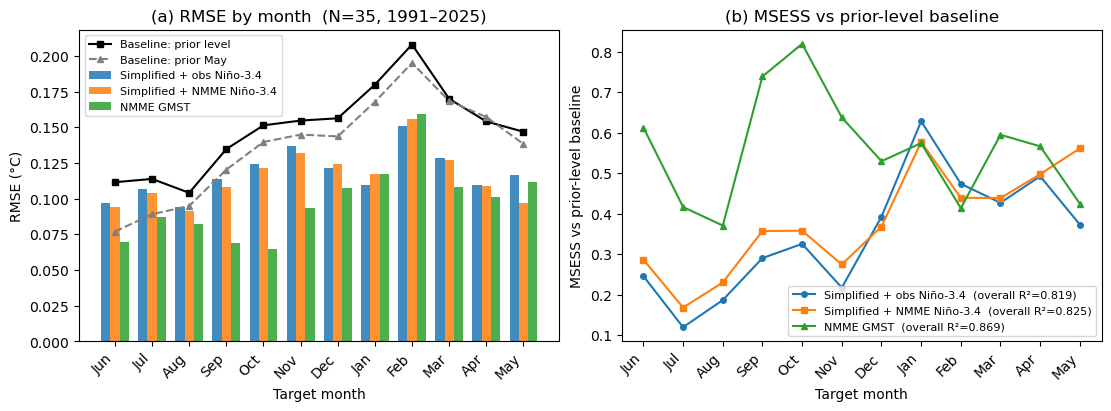

Saved: nmme_skill_comparison.pdf


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout='constrained')

# ── Left: RMSE by month ───────────────────────────────────────────────────
ax = axes[0]
bw = 0.25
x_off = np.array([-bw, 0, bw])

ax.bar(x_eof + x_off[0], rmse_obs_n34,  width=bw, color=colors[0], alpha=0.85,
       label='Simplified + obs Niño-3.4')
ax.bar(x_eof + x_off[1], rmse_nmme_n34, width=bw, color=colors[1], alpha=0.85,
       label='Simplified + NMME Niño-3.4')
ax.bar(x_eof + x_off[2], rmse_nmme_gmt, width=bw, color=colors[2], alpha=0.85,
       label='NMME GMST')

ax.plot(x_eof, rmse_bl_level, color='k',     lw=1.5, marker='s', ms=4, zorder=3,
        label='Baseline: prior level')
ax.plot(x_eof, rmse_bl_may,   color='gray',  lw=1.5, marker='^', ms=4, zorder=3, ls='--',
        label='Baseline: prior May')

ax.set_xticks(x_eof)
ax.set_xticklabels(m_str_jm, rotation=45, ha='right')
ax.set_xlabel('Target month')
ax.set_ylabel('RMSE (°C)')
ax.set_title(f'(a) RMSE by month  (N={N_common}, {COMMON_YEARS[0]}–{COMMON_YEARS[-1]})')
ax.legend(fontsize=8)

# ── Right: MSESS vs level baseline ───────────────────────────────────────
ax = axes[1]
ax.plot(x_eof, msess_obs_n34,  color=colors[0], lw=1.5, marker='o', ms=4,
        label=f'Simplified + obs Niño-3.4  (overall R²={r2_obs_n34:.3f})')
ax.plot(x_eof, msess_nmme_n34, color=colors[1], lw=1.5, marker='s', ms=4,
        label=f'Simplified + NMME Niño-3.4  (overall R²={r2_nmme_n34:.3f})')
ax.plot(x_eof, msess_nmme_gmt, color=colors[2], lw=1.5, marker='^', ms=4,
        label=f'NMME GMST  (overall R²={r2_nmme_gmt:.3f})')

ax.set_xticks(x_eof)
ax.set_xticklabels(m_str_jm, rotation=45, ha='right')
ax.set_xlabel('Target month')
ax.set_ylabel('MSESS vs prior-level baseline')
ax.set_title('(b) MSESS vs prior-level baseline')
ax.legend(fontsize=8, loc='lower right')

fig.savefig(FIGURES_DIR / 'nmme_skill_comparison.pdf', bbox_inches='tight', metadata={'CreationDate': None})
plt.show()
print("Saved: nmme_skill_comparison.pdf")

## Figure — `nmme_trajectory_examples.pdf`: hindcast trajectory panels

3×2 panels (cool years left, warm years right). Four lines per panel: observed,
Simplified+obs Dec N34, Simplified+NMME Dec N34 (±2σ), and NMME GCM MMM (±2σ),
in preindustrial units.

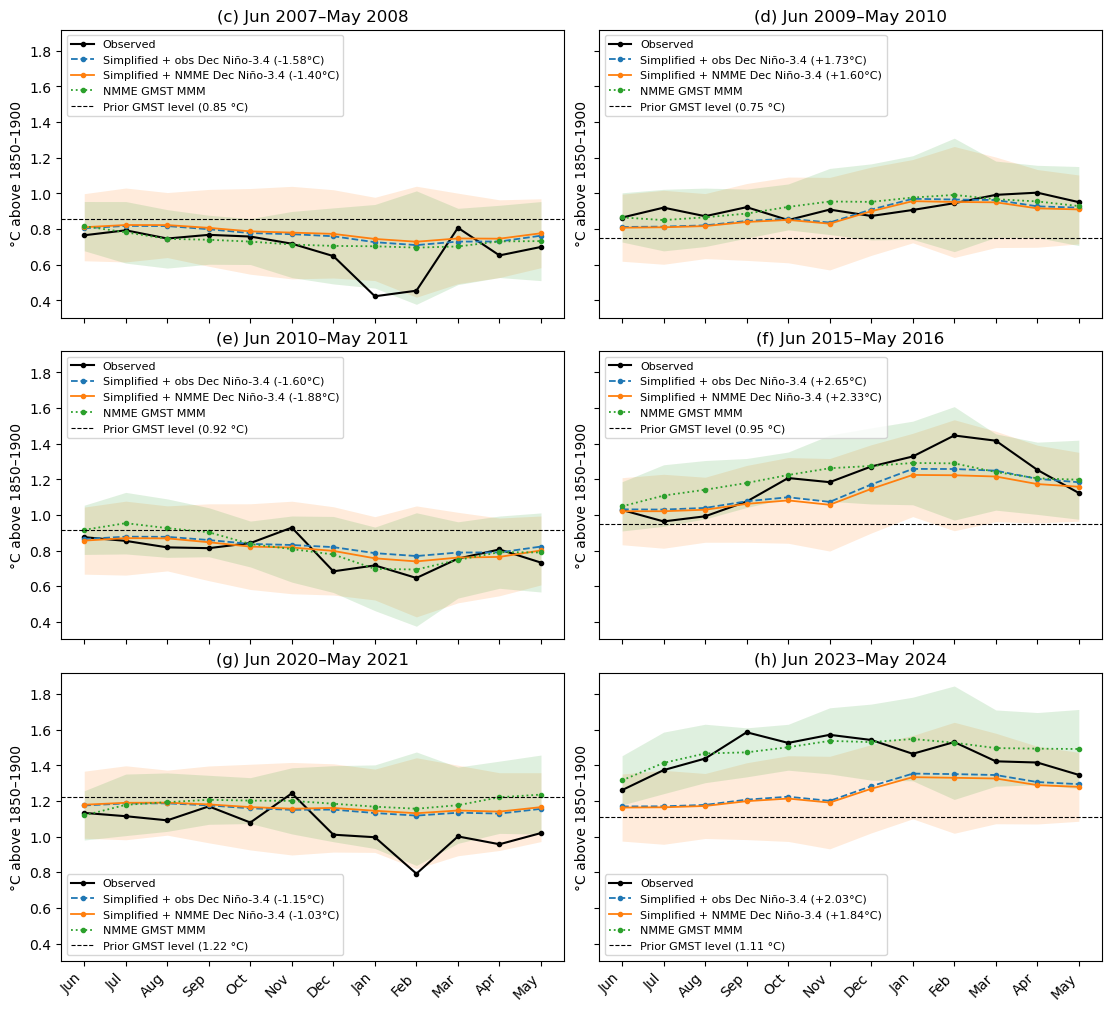

Saved: nmme_trajectory_examples.pdf


In [8]:
# =============================================================================
# FIGURE: nmme_trajectory_examples.pdf
# 3×2 hindcast panels matching hindcast_panels.pdf layout.
# ±2σ prediction intervals for Simplified+NMME Dec N34 and NMME GMST MMM,
# where σ is the per-month std of historical hindcast errors (RMSE period).
# =============================================================================

PANEL_YEARS_COOL = [2007, 2010, 2020]
PANEL_YEARS_WARM = [2009, 2015, 2023]

# Per-month empirical error std over COMMON_YEARS
sigma_nmme_n34 = err_nmme_n34.std(axis=0)   # (12,)
sigma_nmme_gmt = np.nanstd(err_nmme_gmt, axis=0)  # (12,) NaN-safe

# Convert all quantities to preindustrial units (add GMT_PREIND_SHIFT).
# gmt_pred_* and obs_simple are in gmt_june_may (1991–2020 anomaly) space.
obs_preind               = obs_simple            + GMT_PREIND_SHIFT   # (35, 12)
gmt_pred_obs_n34_preind  = gmt_pred_obs_n34      + GMT_PREIND_SHIFT
gmt_pred_nmme_n34_preind = gmt_pred_nmme_n34     + GMT_PREIND_SHIFT
gmt_nmme_fcast_preind    = gmt_nmme_fcast_common + GMT_PREIND_SHIFT

x_months = np.arange(12)
mk = dict(marker='o', ms=3)   # marker style matching hindcast_panels.pdf

fig, axs = plt.subplots(3, 2, figsize=(11, 10), layout='constrained',
                         sharey=True, sharex=True)

for col, year_list in enumerate([PANEL_YEARS_COOL, PANEL_YEARS_WARM]):
    for row, y in enumerate(year_list):
        ax = axs[row, col]
        ci  = int(np.where(COMMON_YEARS == y)[0][0])   # index into 35-year common arrays
        ipr = idx_pred[ci]                               # index into gmt_june_may for prior year

        # Dec N34 legend values (1991–2020 anomaly)
        dec_obs_leg   = dec_n34_era5_display[ci]
        dec_fcast_leg = dec_n34_fcast_display[ci]

        # Prior Jun–May mean in preindustrial units
        pred_level = float(gmt_june_may[ipr, :].mean()) + GMT_PREIND_SHIFT

        ax.plot(x_months, obs_preind[ci],               color='k',        lw=1.5, **mk,
                label='Observed')
        ax.plot(x_months, gmt_pred_obs_n34_preind[ci],  color=colors[0],  lw=1.3, ls='--', **mk,
                label=f'Simplified + obs Dec Niño-3.4 ({dec_obs_leg:+.2f}°C)')
        ax.plot(x_months, gmt_pred_nmme_n34_preind[ci], color=colors[1],  lw=1.3, **mk,
                label=f'Simplified + NMME Dec Niño-3.4 ({dec_fcast_leg:+.2f}°C)')
        ax.fill_between(x_months,
                        gmt_pred_nmme_n34_preind[ci] - 2 * sigma_nmme_n34,
                        gmt_pred_nmme_n34_preind[ci] + 2 * sigma_nmme_n34,
                        color=colors[1], alpha=0.15, lw=0)
        ax.plot(x_months, gmt_nmme_fcast_preind[ci],    color=colors[2],  lw=1.3, ls=':', **mk,
                label='NMME GMST MMM')
        ax.fill_between(x_months,
                        gmt_nmme_fcast_preind[ci] - 2 * sigma_nmme_gmt,
                        gmt_nmme_fcast_preind[ci] + 2 * sigma_nmme_gmt,
                        color=colors[2], alpha=0.15, lw=0)
        ax.axhline(pred_level, color='k', lw=0.8, ls='--',
                   label=f'Prior GMST level ({pred_level:.2f} °C)')

        ax.set_xticks(x_months)
        ax.set_xticklabels(m_str_jm, rotation=45, ha='right')
        letter = chr(ord('c') + row * 2 + col)
        ax.set_title(f'({letter}) Jun {y}–May {y+1}')
        ax.set_ylabel('°C above 1850–1900')

        loc = 'lower left' if row == 2 else 'upper left'
        ax.legend(fontsize=8, loc=loc)

fig.savefig(FIGURES_DIR / 'nmme_trajectory_examples.pdf', bbox_inches='tight', metadata={'CreationDate': None})
plt.show()
print("Saved: nmme_trajectory_examples.pdf")

## Common-period NMME views (shared by the DC-PCA figure and trends table)

`_gmt_p`/`_n34_p` slice the NMME archive to the common period and `_June_p`/
`_June_p_n34` select the June starts. These live inside the cut standard
trajectory-PCA figure in the oracle but are trim-trap intermediates for the
double-centered PCA figure and the trends table below.

In [9]:
_gmt_p = ds_gmt_nmme.sel(S=slice(str(COMMON_YEARS[0]), str(COMMON_YEARS[-1])))
_n34_p = ds_n34_nmme.sel(S=slice(str(COMMON_YEARS[0]), str(COMMON_YEARS[-1])))
_June_p     = _gmt_p.trefa.S.dt.month == 6
_June_p_n34 = _n34_p.ssta.S.dt.month == 6

## Figure — `nmme_traj_dc_pca.pdf`: double-centered trajectory PCA of NMME GMST

Double-centering removes the segment-mean ("level") so DC-PC1 captures the
seasonal shape independent of trend. Each panel shows a model's DC-EOF1 (colored)
against the observed DC-EOF1 (gray), annotated with the level and DC-PC1
couplings to December Niño-3.4 (model vs observed).

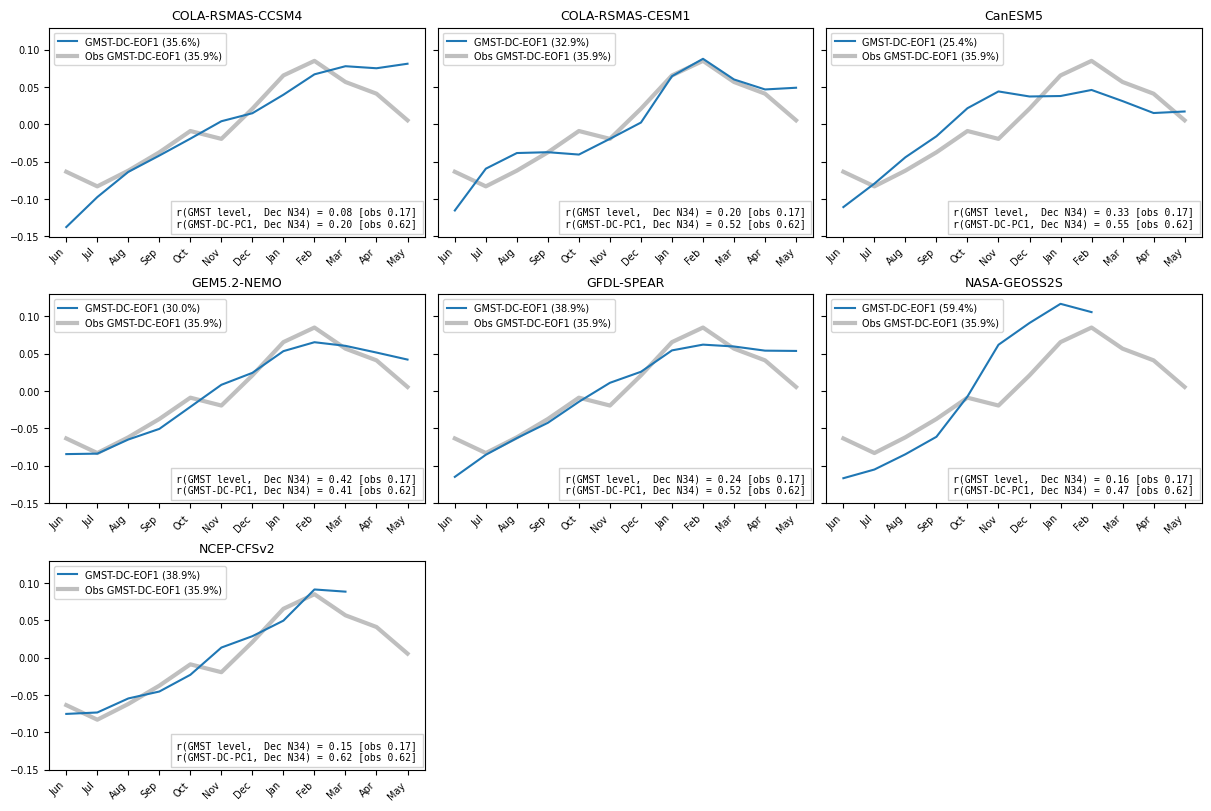

Saved: nmme_traj_dc_pca.pdf


In [10]:
# =============================================================================
# FIGURE: nmme_traj_dc_pca.pdf
# Each panel: model EOF1 (colored) vs observed EOF1 (gray).
# Text: r(PC1, Dec N34) and r(level, Dec N34).
# =============================================================================

fig5, axs5 = plt.subplots(3, 3, sharey=True, figsize=(12, 8), layout='constrained')

# ── Observed reference (double-centered) ─────────────────────────────────
_dta_obs5 = obs_common   # (N_common, 12)
_A_obs5_col = (_dta_obs5 - _dta_obs5.mean(axis=0))
_mask_obs5 = np.isfinite(_A_obs5_col).all(axis=1)
_A_obs5_col = _A_obs5_col[_mask_obs5]
_A_obs5 = (_A_obs5_col.T - _A_obs5_col.mean(axis=1)).T   # remove row means (DC)
EOF_obs5, PC_obs5, _s_obs5 = svd_pca(_A_obs5)
_var_obs5 = _s_obs5[0]**2 / (_s_obs5**2).sum() * 100

if EOF_obs5[8, 0] < 0:
    EOF_obs5[:, 0] *= -1
    PC_obs5[0, :] *= -1

# Obs-reference correlations (from _gmt_p.obs + _n34_p.obs, 1991–2024)
_level_obs5 = _A_obs5_col.mean(axis=1)
_June_p_n34obs = _n34_p.obs.S.dt.month == 6
_dec_n34_obs5 = _n34_p.obs.sel(S=_June_p_n34obs, L=6.5).values[_mask_obs5]
_r_obs_level_n34 = np.corrcoef(_level_obs5, _dec_n34_obs5)[0, 1]
_r_obs_pc1_n34   = np.corrcoef(PC_obs5[0, :], _dec_n34_obs5)[0, 1]
_b_obs_level_n34 = (np.cov(_level_obs5, _dec_n34_obs5)[0, 1]
                    / np.var(_dec_n34_obs5))   # OLS slope: level ~ Dec N34
_b_obs_pc1_n34   = (np.cov(PC_obs5[0, :], _dec_n34_obs5)[0, 1]
                    / np.var(_dec_n34_obs5))   # OLS slope: DC-PC1 ~ Dec N34

for _imod, _model in enumerate(ds_gmt_nmme.model.values):
    _ax = axs5.flatten()[_imod]
    _Mmax = _gmt_p.sel(model=_model).Mmax
    _Lmax = int(_gmt_p.sel(model=_model).Lmax.values)

    _dta5 = (_gmt_p.sel(model=_model, S=_June_p, M=slice(0, _Mmax))
             .trefa.transpose('S', 'M', 'L').values)
    _ny5, _nm5, _ = _dta5.shape
    _N5 = _ny5 * _nm5
    _A5 = _dta5.reshape(_N5, 12)[:, :_Lmax]
    _mask5 = np.isfinite(_A5).all(axis=1)
    _A5 = _A5[_mask5] - _A5[_mask5].mean(axis=0)       # remove column means
    _level5 = _A5.mean(axis=1)                           # segment mean (level)
    _A5 = (_A5.T - _level5).T                            # remove row means
    EOF5, PC5, _s5 = svd_pca(_A5)
    _var5 = _s5[0]**2 / (_s5**2).sum() * 100

    if np.corrcoef(EOF5[:, 0], EOF_obs5[:_Lmax, 0])[0, 1] < 0:
        EOF5[:, 0] *= -1
        PC5[0, :] *= -1

    _ax.plot(EOF_obs5[:, :1], color='gray', lw=3, alpha=0.5)
    _ax.plot(EOF5[:, :1])
    _ax.set_xticks(np.arange(12))
    _ax.set_xticklabels(m_str_jm, rotation=45, ha='right')
    _ax.tick_params(axis='both', labelsize=7)
    _ax.set_title(_model, fontsize=9)

    _dec_n34_5 = (_n34_p.ssta.sel(S=_June_p_n34, model=_model, M=slice(0, _Mmax), L=6.5)
                  .transpose('S', 'M').values.reshape(_N5)[_mask5])
    _r1_5 = np.corrcoef(PC5[0, :], _dec_n34_5)[0, 1]
    _rl_5 = np.corrcoef(_level5, _dec_n34_5)[0, 1]

    # Per-model RMSE over available (year, lead) cells; masked MMM for same cells
    _m_fcast5 = jm_gmta_m.sel(model=_model, S=_gmt_mask).values   # (35, 12), NaN where unavailable
    _err_m5   = _m_fcast5 - obs_common
    _finite5  = np.isfinite(_err_m5)
    _rmse_m5     = np.sqrt(np.mean(_err_m5[_finite5]**2))
    _rmse_mmm_m5 = np.sqrt(np.mean((gmt_nmme_fcast_common - obs_common)[_finite5]**2))

    _ax.text(0.98, 0.04,
             f'r(GMST level,  Dec N34) = {_rl_5:.2f} [obs {_r_obs_level_n34:.2f}]\n'
             f'r(GMST-DC-PC1, Dec N34) = {_r1_5:.2f} [obs {_r_obs_pc1_n34:.2f}]',
             transform=_ax.transAxes, fontsize=7, va='bottom', ha='right',
             family='monospace',
             bbox=dict(facecolor='none', edgecolor='lightgray', pad=4))

    _leg5 = [Line2D([0], [0], color=colors[0], lw=1.5, label=f'GMST-DC-EOF1 ({_var5:.1f}%)'),
             Line2D([0], [0], color='gray', lw=3, alpha=0.5, label=f'Obs GMST-DC-EOF1 ({_var_obs5:.1f}%)')]
    _ax.legend(handles=_leg5, fontsize=7, loc='upper left')

axs5[2, 1].set_axis_off()
axs5[2, 2].set_axis_off()
fig5.savefig(FIGURES_DIR / 'nmme_traj_dc_pca.pdf', bbox_inches='tight', metadata={'CreationDate': None})
plt.show()
print("Saved: nmme_traj_dc_pca.pdf")

## Table — `nmme_trends_table.tex`: GMST-level and Dec Niño-3.4 trends

Linear trends (°C/decade) in GMST level and December Niño-3.4 for each NMME
model and observations over the common period, with 95% CIs from a
year-blocked bootstrap (`seed=42`, `N_BOOT=2000` — deterministic).

In [11]:
# =============================================================================
# TABLE: nmme_trends_table.tex
# =============================================================================

N_BOOT = 2000
_years_p = _gmt_p.trefa.S.sel(S=_June_p).dt.year.values.astype(float)

_tbl_rows = []   # (name, slope_lvl, lo_lvl, hi_lvl, slope_n34, lo_n34, hi_n34)

# ── Observations ─────────────────────────────────────────────────────────────
_dta_obs_tbl = obs_common   # (N_common, 12)
_A_obs_col = _dta_obs_tbl - _dta_obs_tbl.mean(axis=0)
_mask_obs_tbl = np.isfinite(_A_obs_col).all(axis=1)
_level_obs_tbl = _A_obs_col[_mask_obs_tbl].mean(axis=1)
_years_obs_tbl = _years_p[_mask_obs_tbl]
_slope_lvl_obs, _lo_lvl_obs, _hi_lvl_obs = block_bootstrap_trend_decade(
    _years_obs_tbl, _level_obs_tbl, _years_obs_tbl, n_boot=N_BOOT)

_n34_obs_vals = _n34_p.obs.sel(S=_June_p_n34obs, L=6.5).values
_mask_n34_obs = np.isfinite(_n34_obs_vals)
_years_n34_obs = _n34_p.obs.S.sel(S=_June_p_n34obs).dt.year.values.astype(float)[_mask_n34_obs]
_slope_n34_obs, _lo_n34_obs, _hi_n34_obs = block_bootstrap_trend_decade(
    _years_n34_obs, _n34_obs_vals[_mask_n34_obs], _years_n34_obs, n_boot=N_BOOT)

_tbl_rows.append(('Observations',
                  _slope_lvl_obs, _lo_lvl_obs, _hi_lvl_obs,
                  _slope_n34_obs, _lo_n34_obs, _hi_n34_obs))

# ── Models ────────────────────────────────────────────────────────────────────
for _model in ds_gmt_nmme.model.values:
    _Mmax = _gmt_p.sel(model=_model).Mmax
    _Lmax = int(_gmt_p.sel(model=_model).Lmax.values)

    _dta_tbl = (_gmt_p.sel(model=_model, S=_June_p, M=slice(0, _Mmax))
                .trefa.transpose('S', 'M', 'L').values)
    _ny_tbl, _nm_tbl, _ = _dta_tbl.shape
    _N_tbl = _ny_tbl * _nm_tbl
    _A_tbl = _dta_tbl.reshape(_N_tbl, 12)[:, :_Lmax]
    _mask_tbl = np.isfinite(_A_tbl).all(axis=1)
    _A_tbl = _A_tbl[_mask_tbl] - _A_tbl[_mask_tbl].mean(axis=0)
    _level_tbl = _A_tbl.mean(axis=1)
    _year_vec_tbl = np.repeat(_years_p, _nm_tbl)[_mask_tbl]

    _slope_lvl, _lo_lvl, _hi_lvl = block_bootstrap_trend_decade(
        _year_vec_tbl, _level_tbl, _year_vec_tbl, n_boot=N_BOOT)

    _n34_tbl = (_n34_p.ssta.sel(S=_June_p_n34, model=_model, M=slice(0, _Mmax), L=6.5)
                .transpose('S', 'M').values.reshape(_N_tbl)[_mask_tbl])
    _slope_n34, _lo_n34, _hi_n34 = block_bootstrap_trend_decade(
        _year_vec_tbl, _n34_tbl, _year_vec_tbl, n_boot=N_BOOT)

    _tbl_rows.append((_model, _slope_lvl, _lo_lvl, _hi_lvl, _slope_n34, _lo_n34, _hi_n34))

# ── Write LaTeX ───────────────────────────────────────────────────────────────
def _ci(v, lo, hi):
    return f'{v:.2f} [{lo:.2f}, {hi:.2f}]'

_obs_row = None
_model_lines = []
for _name, _sl, _lol, _hil, _sn, _lon, _hin in _tbl_rows:
    _row = f'{_name} & {_ci(_sl, _lol, _hil)} & {_ci(_sn, _lon, _hin)} \\\\'
    if _name == 'Observations':
        _obs_row = _row
    else:
        _model_lines.append(_row)

_tex_lines = [
    r'\begin{tabular}{lcc}',
    r'\hline',
    r'Model & GMST level & Dec Ni\~{n}o-3.4 \\',
    r' & (\textdegree C decade$^{-1}$) & (\textdegree C decade$^{-1}$) \\',
    r'\hline',
] + _model_lines + [
    r'\hline',
    _obs_row,
    r'\hline',
    r'\end{tabular}',
]

_tex_path = TABLES_DIR / 'nmme_trends_table.tex'
_tex_path.write_text('\n'.join(_tex_lines) + '\n')
print(f"Saved: {_tex_path}")

Saved: /Users/tippett/claude/enso-gmt-prediction-capsule/tables/nmme_trends_table.tex


## Table — `nmme_significance_table.tex`: per-month pairwise significance

Per-month p-values (Wilcoxon signed-rank and sign test, both two-sided) for the
two pairwise system comparisons. Bold = p ≤ 0.05.

In [12]:
# =============================================================================
# TABLE: nmme_significance_table.tex
# Comparison 1: Simplified+obs Niño-3.4 vs Simplified+NMME Niño-3.4.
# Comparison 2: Simplified+NMME Niño-3.4 vs NMME GMST.
# =============================================================================

def _fmt_p(p):
    if np.isnan(p):
        return r'---'
    if p < 0.01:
        return r'\textbf{$<$0.01}'
    s = f'{p:.2f}'
    return (r'\textbf{' + s + '}') if p <= 0.05 else s

_hdr = r' & '.join([''] + m_str_jm) + r' \\'

def _tbl_row(label, pvals):
    return label + ' & ' + ' & '.join(_fmt_p(p) for p in pvals) + r' \\'

_sig_tex = [
    r'\begin{tabular}{l*{12}{r}}',
    r'\hline',
    _hdr,
    r'\hline',
    r'\multicolumn{13}{l}{\emph{Simplified + obs Ni\~{n}o-3.4 vs.\ Simplified + NMME Ni\~{n}o-3.4}} \\',
    _tbl_row(r'\quad Wilcoxon', p_wx_obs_vs_nmme_n34),
    _tbl_row(r'\quad Sign test', p_sign_obs_vs_nmme_n34),
    r'\multicolumn{13}{l}{\emph{Simplified + NMME Ni\~{n}o-3.4 vs.\ NMME GMST}} \\',
    _tbl_row(r'\quad Wilcoxon', p_simp_vs_nmme),
    _tbl_row(r'\quad Sign test', p_sign_nmme_n34_vs_gmt),
    r'\hline',
    r'\end{tabular}',
]

_sig_path = TABLES_DIR / 'nmme_significance_table.tex'
_sig_path.write_text('\n'.join(_sig_tex) + '\n')
print(f"Saved: {_sig_path}")


print("\nDone. All plots saved to", FIGURES_DIR)

Saved: /Users/tippett/claude/enso-gmt-prediction-capsule/tables/nmme_significance_table.tex

Done. All plots saved to /Users/tippett/claude/enso-gmt-prediction-capsule/figures
